<img src="logo.png" alt="Vegeta" width="240">

# Project Onager — Onager Atlas, the forklift

The **Atlas** is the Onager series' logistics unit: the Sentinel's wheel-leg chassis (notebook 20) carrying a
forklift — a tilting mast of two steel uprights ahead of the front wheels, a lift carriage and two forks for
Euro-pallet openings — and a counterweight under the rear of the hull. It picks up a loaded pallet on rough
ground, carries it and sets it down. Its legs do what a forklift's rigid axles cannot: they set a **logistics
stance** (legs nearly straight under the load, so the knee modules carry it through the structure) and they keep
four wheels on uneven ground.

Design targets (inputs): **200 kg** at a **500 mm** load centre (a Euro pallet with a 175 kg crate), **1.2 m** of
lift, **1 m/s** loaded on gravel. The notebook checks them end to end with the Vegeta libraries:

```
CAD (Dedalus): chassis + mast + carriage + forks + counterweight ─► masses, CG, envelope
stability: the load chart (tipping about the front wheels, braking, lift height) and the knee-limited capacity
the stance: front knee and shoulder torques vs the leg angles ─► why the logistics stance
the drives (actuators.py, linear): lift and tilt forces vs load and height, speeds on the torque–speed line, energy
forks and mast (Talos): fork stress at the rated and the proof load, mast modes with the load at two heights
ride with a load: quarter car of a front corner on gravel ─► does the pallet stay on the forks
MuJoCo (ChironLab, Chiron props): the pallet job — approach, lift, carry 8 m, set down — and a movie
```

In [ ]:
# DEBUG: test the notebook end to end before the full run. On: FEA and CFD are mocked (vegeta.mock: fixed numbers,
# seconds instead of hours, the result cache off). Turn it on here or from the shell:
#   VEGETA_DEBUG=1 jupyter nbconvert --to notebook --execute <notebook>.ipynb --output <notebook>-run.ipynb
DEBUG = False
from vegeta import mock
DEBUG = mock.setup(DEBUG)

In [1]:
import json, math, shutil, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from vegeta import dedalus, talos, chronos, chiron
from vegeta.dedalus import viz as dviz
from vegeta.talos import viz as tviz
from vegeta.chiron import viz as cviz
sys.path.insert(0, "designs")
import actuators as act                   # the shared actuator / motor / joint library
import onager_robot as orb, onager_controller as oc                       # the Onager chassis (notebook 20)
import onager_atlas_robot as oar, onager_atlas_scenario as oas            # the Atlas in ChironLab

RUNS = Path("_runs/onager_atlas"); shutil.rmtree(RUNS, ignore_errors=True); RUNS.mkdir(parents=True)
OUT = Path("output/21_onager_atlas"); OUT.mkdir(parents=True, exist_ok=True)
for f in ("onager.py", "onager_atlas.py"):
    shutil.copy(Path("designs") / f, RUNS / f)
sys.path.insert(0, str(RUNS))
design = dedalus.load_design(f"{RUNS / 'onager_atlas.py'}:OnagerAtlas")
G = 9.81
TARGETS = pd.Series({"rated load [kg]": 200, "load centre [mm]": 500, "lift height [mm]": 1200, "speed loaded [m/s]": 1.0,
                     "pallet": "Euro 1200 x 800 + 175 kg crate"}, name="Onager Atlas — design targets (inputs)")
display(TARGETS.to_frame())
pd.DataFrame(design.params.table()).set_index("name").loc[list(oar.ATLAS) + list(oar.CHASSIS)]

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Onager Atlas — design targets (inputs)
rated load [kg],200
load centre [mm],500
lift height [mm],1200
speed loaded [m/s],1.0
pallet,Euro 1200 x 800 + 175 kg crate


,default,units,min,max,description
name,,,,,
pivot_x,1200.0,mm,0.0,NaN,mast tilt pivot ahead of the hull centre
pivot_z,1065.0,mm,0.0,NaN,mast tilt pivot above the ground (standing)
upright_y,320.0,mm,50.0,NaN,uprights either side of the centre line
upright_width,60.0,mm,10.0,NaN,"rectangular tube, across (y)"
upright_depth,100.0,mm,10.0,NaN,"rectangular tube, fore-aft (x)"
upright_wall,6.0,mm,1.0,NaN,S355 tube wall
mast_bottom,-1005.0,mm,NaN,NaN,uprights' lower end relative to the pivot
mast_top,1020.0,mm,NaN,NaN,uprights' upper end relative to the pivot
carriage_offset,80.0,mm,0.0,NaN,carriage plate ahead of the uprights' axis


## 1. The machine

The Sentinel's hull and wheel-legs, no turret (the sensor mast stays), the forklift on two arms from the hull's
nose: a tilt pivot under the nose, uprights from 60 mm above the ground to 2.1 m, the carriage running on them and
two forks 1000 mm long, 80 × 30 mm S690 steel, at ±175 mm — the middle of a Euro pallet's two fork openings.
The legs stand in the **logistics stance** (upper legs 25°, lower legs 15° from vertical, Sentinel 40° / 55°), so
the hull rides 285 mm higher than the Sentinel's.

shoulders 1.273 m up | front axle 0.820 m ahead of the hull centre, wheel front 1.100 m | mast pivot 1.20 m | fork heels 1.375 m | load centre (500 mm) 1.875 m | wheelbase 1.80 m


/home/user/vegeta/vegeta-cli/src/vegeta/dedalus/viz.py:108: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


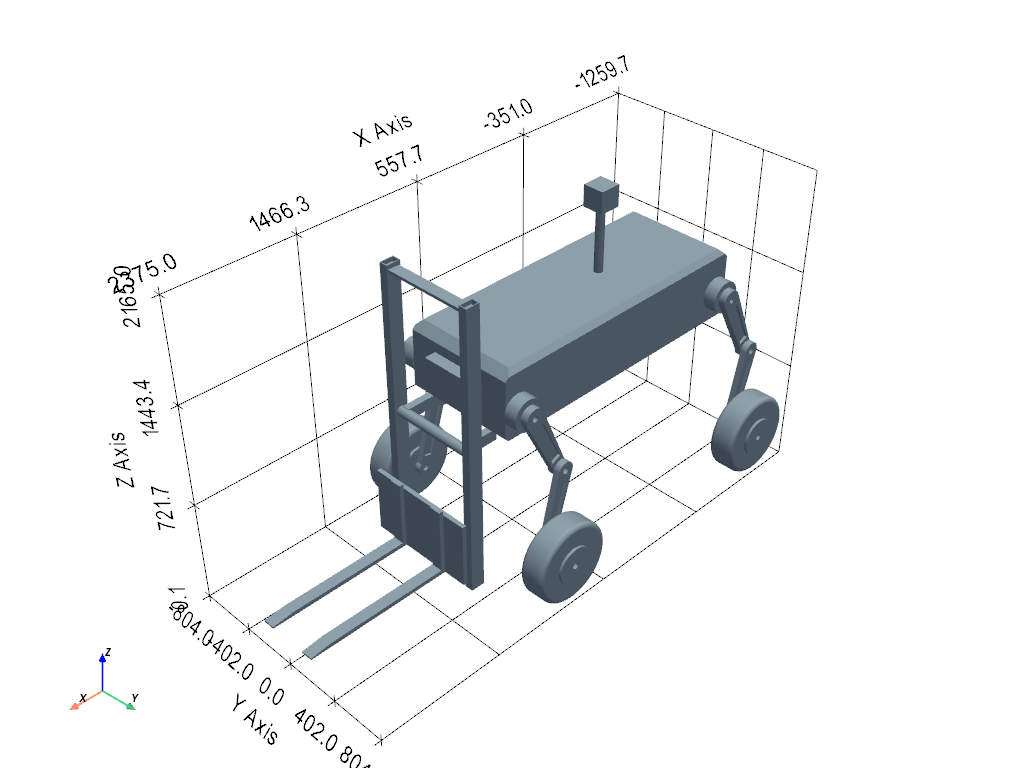

In [2]:
p = design.resolve()
parts = {k: design.generate(part=k) for k in ("robot", "hull", "fork", "mast")}
cad = {k: g.export(RUNS / "cad" / k, stl_tolerance=0.1) for k, g in parts.items()}
geo = orb.geometry(oar.design_params())
fl = oar.forklift_geometry()
x_front = geo["shoulder_x"] + geo["axle_x"]
print(f"shoulders {geo['shoulder_height']:.3f} m up | front axle {x_front:.3f} m ahead of the hull centre, wheel front {x_front + geo['r_wheel']:.3f} m | "
      f"mast pivot {fl['pivot'][0]:.2f} m | fork heels {fl['heel_world_x']:.3f} m | load centre (500 mm) {fl['heel_world_x'] + 0.5:.3f} m | wheelbase {geo['wheelbase']:.2f} m")
dviz.show(dviz.plot3d(parts["robot"]))

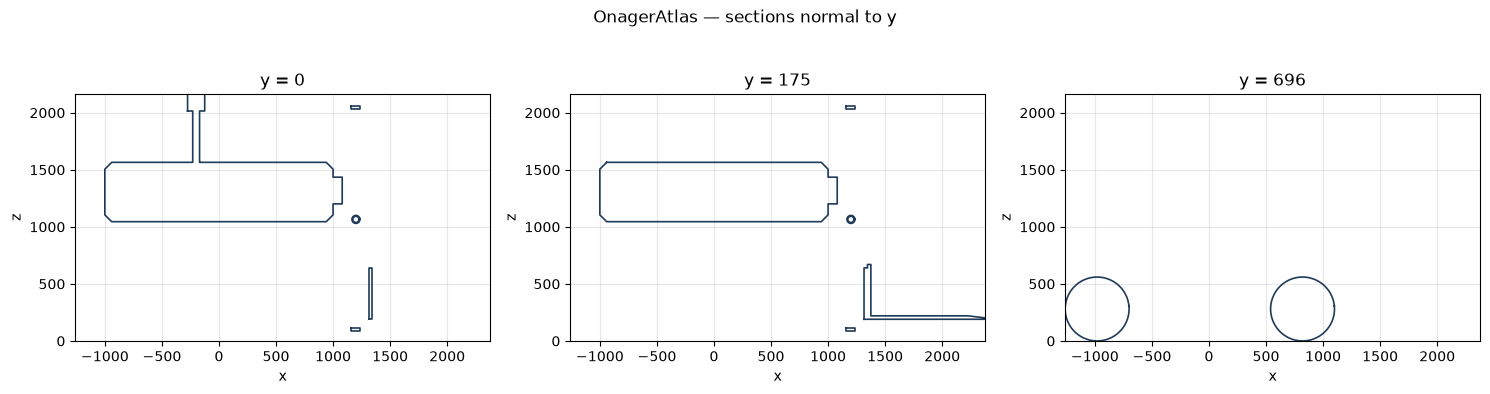

In [3]:
fig = dviz.plot_sections(parts["robot"], normal="y", positions=[0.0, p["fork_y"], geo["y_wheel"] * 1000], cols=3)

In [4]:
cad_num = oar.cad_numbers(oar.design_params(), recompute=True)
assert max(abs(cad_num[k] / oar.CAD[k] - 1) for k in oar.CAD) < 0.01
budget = oar.mass_budget(cad=cad_num)
mass = pd.DataFrame({"mass [kg]": budget}); M = mass["mass [kg]"].sum(); mass.loc["TOTAL"] = M
fork_mass = pd.DataFrame({"mass [kg]": oar.forklift_masses(cad=cad_num)})
robot = oar.atlas(cad=cad_num)
lab_flat = oar.atlas_lab(chiron.Flat(), robot=robot)
ep_stand = lab_flat.run(oc.Stand(), duration=2.0, rules=None, settle=0.0)
fz_stand = np.asarray(ep_stand.log["foot_force"])[-1, :, 2]
com = np.asarray(ep_stand.log["com"])[-1]
X_CG, Z_CG = float(com[0]), float(com[2])
print(f"Atlas {M:.0f} kg (Sentinel 408 kg; forklift {fork_mass['mass [kg]'].sum():.0f} kg, counterweight {oar.COUNTERWEIGHT['mass_kg']:.0f} kg) | "
      f"CG {X_CG * 1000:+.0f} mm from the hull centre, {Z_CG:.2f} m up | wheels FL FR RL RR {fz_stand.round(0)} N")
display(fork_mass.round(1))
mass.round(1)

Atlas 726 kg (Sentinel 408 kg; forklift 210 kg, counterweight 120 kg) | CG -17 mm from the hull centre, 0.91 m up | wheels FL FR RL RR [2243. 2243. 1320. 1320.] N


,mass [kg]
"forks 2x (S690, CAD)",54.1
"mast (S355 uprights, CAD)",81.7
carriage frame (welded),30.0
mast mount arms,12.0
lift screw 8 kN,12.0
tilt screws 2x (12 kN),12.0
"lift chain, rollers, guards",8.0


,mass [kg]
"armour shell, 3 mm Al 5083 (from CAD area)",50.2
"upper legs 4x (Al 7075-T6, from CAD)",30.5
"lower legs 4x (Al 7075-T6, from CAD)",23.8
"leg actuators 8x (cycloidal 800 Nm, brake; 11.0 kg each)",88.0
hub motors 4x (hub motor 3 kW; 9.0 kg each),36.0
"frame, mounts, hatches",28.0
wheels: tyres + rims 4x,44.0
battery 48 V LFP 6 kWh,55.0
"computer, radios, relay, IMU",12.0
"wiring, connectors, cooling",15.0


## 2. Stability: the load chart

The Atlas tips over its front wheels when the load's moment about the front contact line exceeds the robot's:
`m_L [g (x_L − x_F) + a h_L] ≤ m_R [g (x_F − x_R) − a h_R] / SF`, with `x_F` the front contact line, `x_R`, `h_R`
the robot's CG (from ChironLab, standing), `x_L`, `h_L` the load's CG (the pallet's centre of mass at the load
centre, at the lift height), `a` a braking deceleration and SF = 1.5 (inputs). A second limit is the front knee
modules: the front axle carries more as the load grows, and each knee holds its wheel's force on the lever
`L₂ sin a₂` — with the 800 N·m `cycloidal 800 Nm, brake`. The capacity is the smaller of the two.

,"tipping/1.5, static [kg]","tipping/1.5, braking 1 m/s², 1.2 m up [kg]",front knees at stall [kg],capacity [kg]
400 mm,424.0,321.0,509.0,321.0
500 mm,384.0,295.0,491.0,295.0
600 mm,351.0,273.0,474.0,273.0
800 mm,299.0,237.0,444.0,237.0


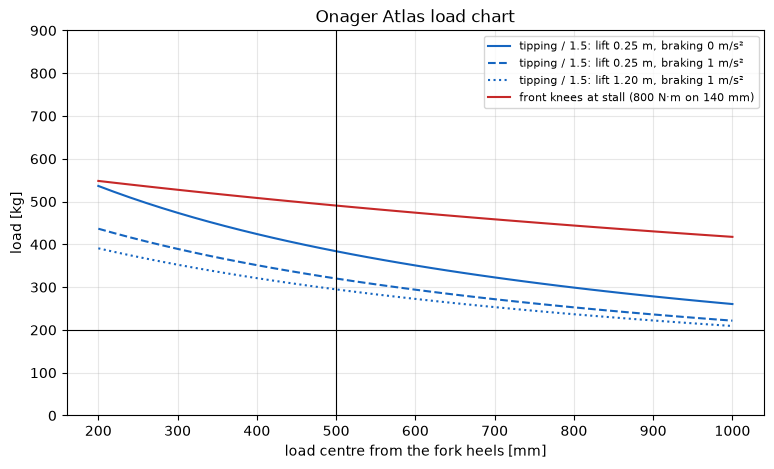

In [5]:
SF_TIP = 1.5
KNEE = act.get(orb.LEG_ACTUATOR)
x_rear = -geo["shoulder_x"] + geo["axle_x"]
LEVER_KNEE = geo["L2"] * math.sin(geo["a2"])
H_PALLET_CG = oas.PALLET["height"] + 0.5 * oas.PALLET["crate"][2] * oas.PALLET["crate_kg"] / oas.PALLET["total_kg"]   # above the forks' top
def capacity(c_mm, lift_m=0.25, a=0.0):
    x_l = fl["heel_world_x"] + c_mm / 1000
    h_l = lift_m + fl["fork_t"] + H_PALLET_CG
    tip = M * (G * (x_front - X_CG) - a * Z_CG) / (SF_TIP * (G * (x_l - x_front) + a * h_l))
    # knees: front axle force with a load m: (M g (x_cg - x_rear) + m g (x_l - x_rear)) / wheelbase, per wheel / 2
    wheel_max = KNEE.stall_Nm / LEVER_KNEE
    knee = (2 * wheel_max * geo["wheelbase"] / G - M * (X_CG - x_rear)) / (x_l - x_rear)
    return tip, knee
cs = np.linspace(200, 1000, 41)
fig, ax = plt.subplots(figsize=(9, 5))
for lift_m, a, ls in ((0.25, 0.0, "-"), (0.25, 1.0, "--"), (1.2, 1.0, ":")):
    ax.plot(cs, [capacity(c, lift_m, a)[0] for c in cs], ls, color="#1565c0", label=f"tipping / {SF_TIP}: lift {lift_m:.2f} m, braking {a:.0f} m/s²")
ax.plot(cs, [capacity(c)[1] for c in cs], color="#c62828", label=f"front knees at stall ({KNEE.stall_Nm:.0f} N·m on {LEVER_KNEE * 1000:.0f} mm)")
ax.axhline(TARGETS["rated load [kg]"], color="k", lw=0.8); ax.axvline(TARGETS["load centre [mm]"], color="k", lw=0.8)
ax.set(xlabel="load centre from the fork heels [mm]", ylabel="load [kg]", ylim=(0, 900), title="Onager Atlas load chart"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
chart = pd.DataFrame({f"{c:.0f} mm": {"tipping/1.5, static [kg]": capacity(c)[0], "tipping/1.5, braking 1 m/s², 1.2 m up [kg]": capacity(c, 1.2, 1.0)[0],
                                      "front knees at stall [kg]": capacity(c)[1]} for c in (400, 500, 600, 800)}).T
chart["capacity [kg]"] = chart.min(axis=1)
chart.round(0)

## 3. The stance: why the legs stand nearly straight

The front wheel's force acts on the knee through the lower leg's horizontal reach `L₂ sin a₂` and on the shoulder
through the whole leg's `|x_axle|`. Sweeping the two standing angles with the rated pallet on the forks shows the
Sentinel's stance (40°/55°, built for suspension travel) overloading the knee modules, and the region where both
joints stay inside the 800 N·m modules with margin. The price of the straight stance is a stiff ride (the knee's
servo stiffness seen at the wheel, `kp / (L₂ sin a₂)²`, grows as the lever shrinks) and a higher hull.

,knee [N·m],shoulder [N·m],wheel stiffness kp/(L2 sin a2)² [kN/m],shoulder height [m]
Sentinel 40°/55°,1531.5,374.2,8.2,1.0
Atlas 25°/15°,483.9,277.0,81.9,1.3


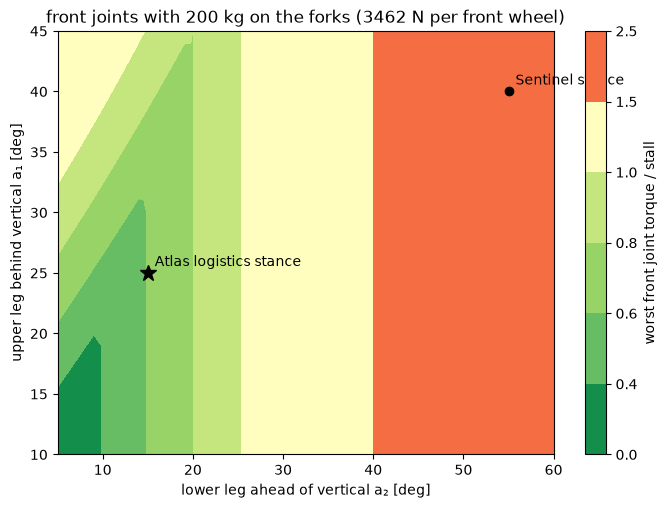

In [6]:
L1, L2 = geo["L1"], geo["L2"]
m_load = TARGETS["rated load [kg]"]
x_l = fl["heel_world_x"] + 0.5
F_front = (M * G * (X_CG - x_rear) + m_load * G * (x_l - x_rear)) / geo["wheelbase"] / 2       # per front wheel [N]
a1s, a2s = np.linspace(10, 45, 36), np.linspace(5, 60, 56)
A1, A2 = np.meshgrid(np.radians(a1s), np.radians(a2s), indexing="ij")
knee = F_front * L2 * np.sin(A2)
shoulder = F_front * np.abs(-L1 * np.sin(A1) + L2 * np.sin(A2))
worst = np.maximum(knee, shoulder) / KNEE.stall_Nm
fig, ax = plt.subplots(figsize=(8, 5.5))
cs_ = ax.contourf(a2s, a1s, worst, levels=[0, 0.4, 0.6, 0.8, 1.0, 1.5, 2.5], cmap="RdYlGn_r")
fig.colorbar(cs_, ax=ax, label="worst front joint torque / stall")
ax.plot(55, 40, "ko"); ax.annotate("Sentinel stance", (55, 40), xytext=(5, 5), textcoords="offset points")
ax.plot(math.degrees(geo["a2"]), math.degrees(geo["a1"]), "k*", ms=12); ax.annotate("Atlas logistics stance", (math.degrees(geo["a2"]), math.degrees(geo["a1"])), xytext=(5, 5), textcoords="offset points")
ax.set(xlabel="lower leg ahead of vertical a₂ [deg]", ylabel="upper leg behind vertical a₁ [deg]", title=f"front joints with {m_load} kg on the forks ({F_front:.0f} N per front wheel)")
stance = pd.DataFrame({name: {"knee [N·m]": F_front * L2 * math.sin(math.radians(b)), "shoulder [N·m]": F_front * abs(-L1 * math.sin(math.radians(a)) + L2 * math.sin(math.radians(b))),
                              "wheel stiffness kp/(L2 sin a2)² [kN/m]": orb.LEG_KP / (L2 * math.sin(math.radians(b))) ** 2 / 1000,
                              "shoulder height [m]": L1 * math.cos(math.radians(a)) + L2 * math.cos(math.radians(b)) + geo["r_wheel"]}
                       for name, (a, b) in {"Sentinel 40°/55°": (40, 55), "Atlas 25°/15°": (math.degrees(geo["a1"]), math.degrees(geo["a2"]))}.items()}).T
stance.round(1)

## 4. The lift and tilt drives

Two linear drives from the catalogue (`actuators.LINEAR`): the **lift screw** (8 kN stall, 200 mm/s no load,
braked) raises the carriage, the forks and the load; the **tilt screws** (12 kN on a 0.30 m lever) tilt the mast
against the load's moment about the pivot. Both run on their force–speed lines: the loaded lift speed is
`v₀ (1 − F/F_stall)`. Mechanical work and a DC-motor estimate of the electrical energy give the cost of a lift.

rated lift: 3095 N (0.39 of stall, above the 3000 N continuous) | 123 mm/s, full height in 9.8 s | 2.20 Wh per full lift (DC estimate) — 0.037 % of the battery


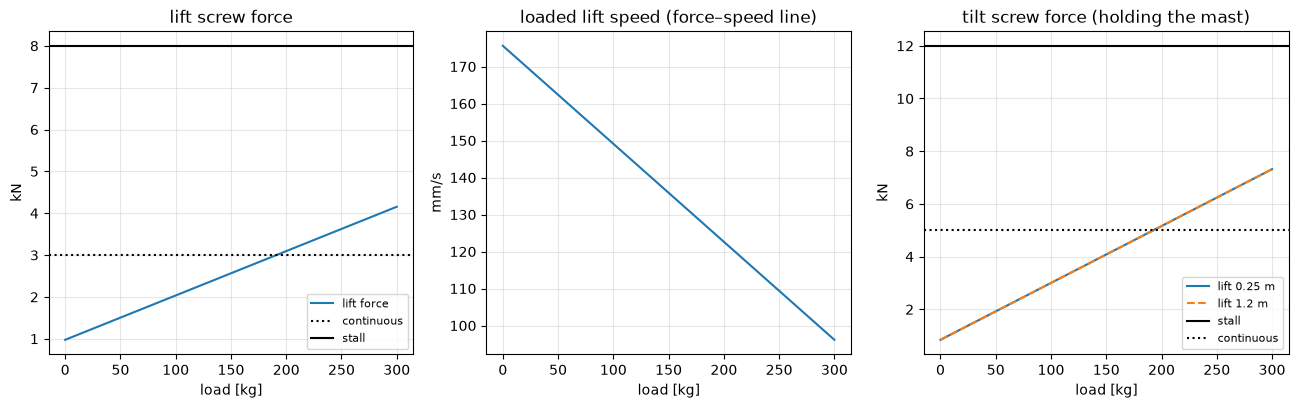

In [7]:
LIFT, TILT = act.get_linear(oar.LIFT), act.get_linear(oar.TILT)
m_carriage = oar.FORKLIFT_KG["carriage frame (welded)"] + oar.forklift_masses(cad=cad_num)["forks 2x (S690, CAD)"] + oar.FORKLIFT_KG["lift chain, rollers, guards"]
FRICTION = 0.08                           # mast rollers and the screw: 8 % of the load (input)
loads = np.linspace(0, 300, 31)
F_lift = (m_carriage + loads) * G * (1 + FRICTION)
v_lift = LIFT.no_load_mm_s / 1000 * np.clip(1 - F_lift / LIFT.stall_N, 0, 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(loads, F_lift / 1000, label="lift force"); axes[0].axhline(LIFT.rated_N / 1000, color="k", ls=":", label="continuous"); axes[0].axhline(LIFT.stall_N / 1000, color="k", label="stall")
axes[0].set(xlabel="load [kg]", ylabel="kN", title="lift screw force"); axes[0].legend(fontsize=8)
axes[1].plot(loads, v_lift * 1000); axes[1].set(xlabel="load [kg]", ylabel="mm/s", title="loaded lift speed (force–speed line)")
# tilt: the load's moment about the pivot at lift heights, mast vertical
pz = fl["pivot_z_world"]
for lift_m, ls in ((0.25, "-"), (1.2, "--")):
    x_arm = fl["carriage_x"] + fl["fork_t"] + 0.5                                   # load centre ahead of the pivot
    M_tilt = loads * G * x_arm + m_carriage * G * (fl["carriage_x"] + 0.15)
    axes[2].plot(loads, M_tilt / oar.TILT_LEVER / 1000, ls, label=f"lift {lift_m} m")
axes[2].axhline(TILT.stall_N / 1000, color="k", label="stall"); axes[2].axhline(TILT.rated_N / 1000, color="k", ls=":", label="continuous")
axes[2].set(xlabel="load [kg]", ylabel="kN", title="tilt screw force (holding the mast)"); axes[2].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.3)
F_rated = (m_carriage + m_load) * G * (1 + FRICTION)
v_rated = LIFT.no_load_mm_s / 1000 * (1 - F_rated / LIFT.stall_N)
t_full = fl["lift_max"] / v_rated
kt = LIFT.stall_N / LIFT.stall_A                      # N per A (stall point)
I = F_rated / kt
E_lift = (F_rated * fl["lift_max"] + I ** 2 * (LIFT.voltage_V / LIFT.stall_A) * t_full) / 3600
print(f"rated lift: {F_rated:.0f} N ({F_rated / LIFT.stall_N:.2f} of stall, {'above' if F_rated > LIFT.rated_N else 'within'} the {LIFT.rated_N:.0f} N continuous) | "
      f"{v_rated * 1000:.0f} mm/s, full height in {t_full:.1f} s | {E_lift:.2f} Wh per full lift (DC estimate) — "
      f"{E_lift / 6000 * 100:.3f} % of the battery")

## 5. Forks and mast (Talos)

**Forks.** Each fork is analysed in its own frame: the shank's back face held (the hook-on carriage), the load
spread over the tine's flat top face (heel to 850 mm, where the tip taper starts; its resultant 425 mm out) and
scaled by 500/425 so the heel sees the moment of the case's load at the 500 mm load centre. Cases: half the rated
load × a dynamic factor 2 (gravel, braking), and the proof load (3 × rated, the usual fork test) — the heel corner
is the critical spot; beam theory (the tine as a cantilever, the load at 500 mm) checks it.

**Mast.** The two uprights and their crossbars (the analysis part ``mast_fea`` adds the tilt screws' cross-bar
and the carriage's roller beam at the lift height), held at the pivot and at the tilt bar, carry the carriage, the
forks and the pallet as a lumped mass on the roller beam: its first modes are the mast's sway with the load, which a
forklift excites when it brakes and on bumps.

In [8]:
S690 = talos.Material("S690QL fork steel", youngs_modulus=210000.0, poissons_ratio=0.30, density=7.85e-9, yield_strength=690.0, source="EN 10025-6")
S355 = talos.Material("S355 mast tube", youngs_modulus=210000.0, poissons_ratio=0.30, density=7.85e-9, yield_strength=355.0, source="EN 10025-2")
t, w = p["fork_thickness"], p["fork_width"]
FORK_REGIONS = [talos.SurfacesOnPlane("back", "x", -t), talos.SurfacesInBox("seat", (-1.0, -w, t - 0.5, 851.0, w, t + 0.5))]
SEAT_SCALE = 500.0 / 425.0                 # the spread load's heel moment equals the case's load at 500 mm
def fork_model(load_N, name):
    return talos.StructuralModel(cad["fork"].artifacts["step"], "mm-N-MPa", S690, FORK_REGIONS, [talos.FixedSupport("back")],
                                 [talos.Force("seat", fz=-load_N * SEAT_SCALE)], talos.MeshSettings(element_size=8.0, min_element_size=2.5), name=name)
FORK_CASES = {"rated × 2 (dynamic), per fork": m_load * G / 2 * 2, "proof 3 × rated, per fork": m_load * G / 2 * 3}
fork_res = {}
for name, F in tqdm(FORK_CASES.items(), desc="fork cases"):
    key = name.split(",")[0].replace(" ", "_").replace("×", "x")
    fm = fork_model(F, key); fm.mesh(RUNS / f"fork_{key}"); fork_res[name] = fm.solve(RUNS / f"fork_{key}")
def beam(F):                               # the tine as a cantilever, the load at the 500 mm load centre
    Mb = F * 500.0; Z = w * t ** 2 / 6
    return Mb / Z, F * 500.0 ** 2 * (3 * 1000 - 500.0) / (6 * 210000 * w * t ** 3 / 12)
forks = pd.DataFrame({k: {"load [N]": FORK_CASES[k], "max von Mises [MPa]": r.metrics.get("max_von_mises"), "SF yield": r.metrics.get("safety_factor_yield"),
                          "tip deflection [mm]": r.metrics.get("max_displacement"), "beam: root stress [MPa]": beam(FORK_CASES[k])[0], "beam: tip deflection [mm]": beam(FORK_CASES[k])[1]}
                      for k, r in fork_res.items()}).T
forks.round(2)

fork cases:   0%|          | 0/2 [00:00<?, ?it/s]

fork cases:  50%|█████     | 1/2 [00:19<00:19, 19.49s/it]

fork cases: 100%|██████████| 2/2 [00:37<00:00, 18.81s/it]

fork cases: 100%|██████████| 2/2 [00:37<00:00, 18.92s/it]

,load [N],max von Mises [MPa],SF yield,tip deflection [mm],beam: root stress [MPa],beam: tip deflection [mm]
"rated × 2 (dynamic), per fork",1962.0,103.81,6.65,6.15,81.75,5.41
"proof 3 × rated, per fork",2943.0,155.72,4.43,9.23,122.62,8.11


/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:155: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.25, line_width=0.5)
/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:323: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


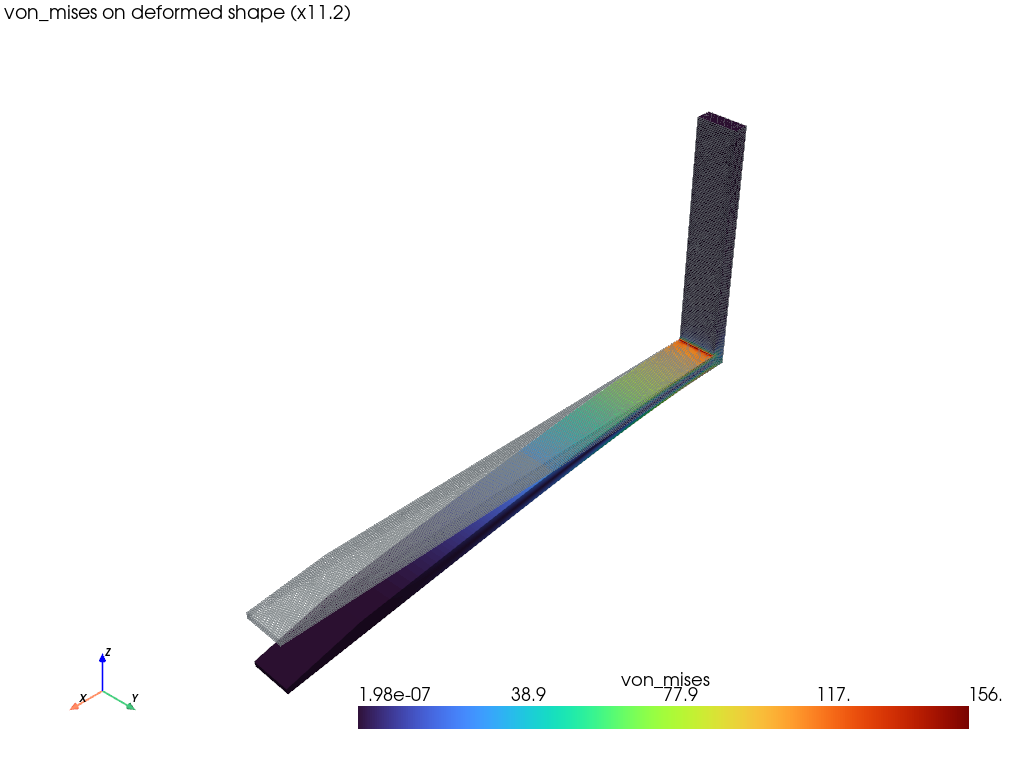

In [9]:
tviz.show(tviz.plot_results(fork_res["proof 3 × rated, per fork"], field="von_mises"))

lift 0.25 m: success ['frequencies are undamped and linear (no stress stiffening, no pre-load); printed parts are anisotropic and often softer than the datasheet modulus']


lift 1.2 m: success ['frequencies are undamped and linear (no stress stiffening, no pre-load); printed parts are anisotropic and often softer than the datasheet modulus']
excitation at 1.0 m/s loaded: wheel 1/rev 0.57 Hz; terrain (wavelengths 0.3–10 m) 0.10–3.3 Hz


/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:255: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.3, line_width=0.5)
/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:323: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


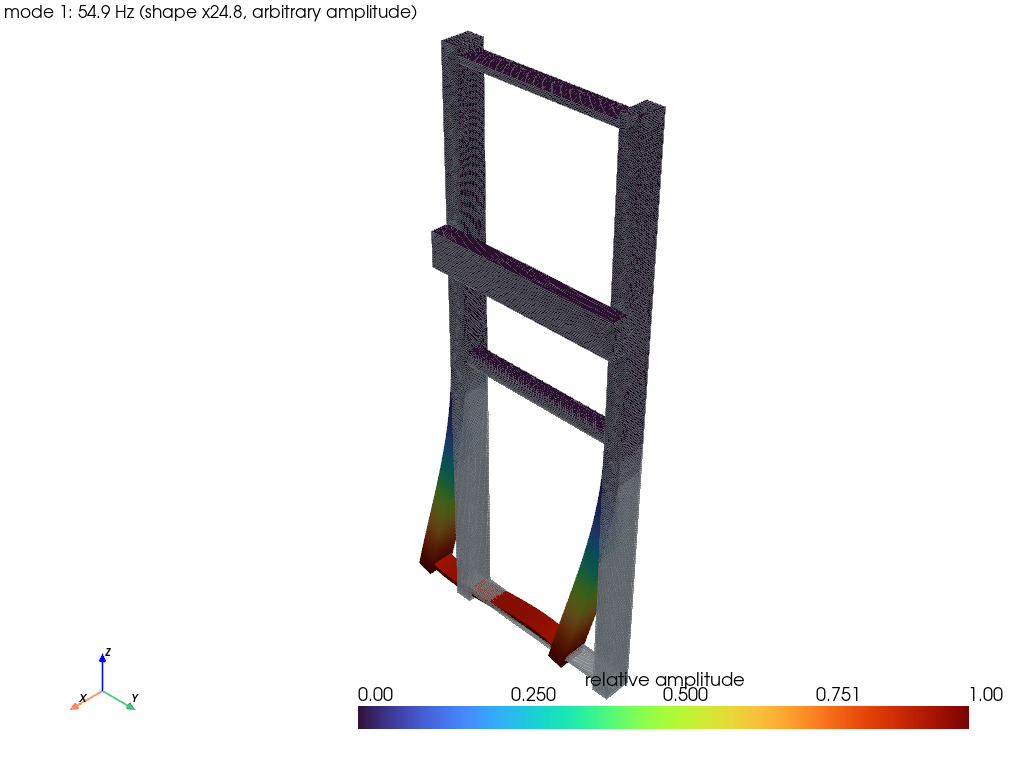

,mode 1 [Hz],mode 2 [Hz],mode 3 [Hz],mode 4 [Hz]
lift 0.25 m,29.9,38.8,73.0,90.5
lift 1.2 m,54.9,69.0,100.9,108.4


In [10]:
d, uy, wu = p["upright_depth"], p["upright_y"], p["upright_width"]
span = 2 * uy + wu
mast_modes = {}
for lift_m in (0.25, 1.2):
    part = design.generate(part="mast_fea", lift=lift_m * 1000)
    step = part.export(RUNS / "cad" / f"mast_fea_{lift_m}", stl_tolerance=0.1).artifacts["step"]
    z_c = (p["fork_ground"] - p["pivot_z"]) + lift_m * 1000 + p["carriage_height"] / 2
    regions = [talos.SurfacesInBox("pivot", (-40, -span / 2 - 1, -40, 40, span / 2 + 1, 40)),
               talos.SurfacesInBox("tilt_bar", (-0.4 * d - 1, -span / 2 - 1, 279, -0.4 * d + 1, span / 2 + 1, 321)),
               talos.SurfacesInBox("carriage", (d / 2 + 59, -span / 2 - 1, z_c - 61, d / 2 + 61, span / 2 + 1, z_c + 61))]
    mm_ = talos.StructuralModel(step, "mm-N-MPa", S355, regions, [talos.FixedSupport("pivot"), talos.FixedSupport("tilt_bar")], [],
                                talos.MeshSettings(element_size=14.0, min_element_size=4.0), name=f"mast_{lift_m}",
                                masses=[talos.PointMass("carriage", (m_carriage + m_load) * 1e-3)])
    mm_.mesh(RUNS / f"mast_{lift_m}")
    mast_modes[f"lift {lift_m} m"] = mm_.solve_modes(RUNS / f"mast_{lift_m}", n_modes=4)
    print(f"lift {lift_m} m: {mast_modes[f'lift {lift_m} m'].status} {mast_modes[f'lift {lift_m} m'].messages[:1]}")
modes_tab = pd.DataFrame({k: r.metrics["frequencies_hz"] for k, r in mast_modes.items()}, index=[f"mode {i + 1} [Hz]" for i in range(4)]).T
v_loaded = TARGETS["speed loaded [m/s]"]
print(f"excitation at {v_loaded} m/s loaded: wheel 1/rev {v_loaded / (2 * math.pi * geo['r_wheel']):.2f} Hz; terrain (wavelengths 0.3–10 m) {v_loaded / 10:.2f}–{v_loaded / 0.3:.1f} Hz")
tviz.show(tviz.plot_mode(mast_modes["lift 1.2 m"], mode=1))
modes_tab.round(1)

## 6. Ride with a load: does the pallet stay on the forks?

A quarter car of a front corner in the logistics stance: the sprung mass is the corner's share of the robot and the
pallet, the spring the knee servo seen at the wheel (`kp / (L₂ sin a₂)²`, stiff in this stance), the tyre 150 kN/m.
ISO 8608 gravel (class C) at the loaded speed and at a travel speed. The pallet rests on the forks by its weight:
where the hull's vertical acceleration drops below −g the pallet would leave the forks for an instant.

,sprung mass [kg],heave [Hz],hull accel RMS [g],hull accel min [g],time below −g [%],wheel load max [N],front knee max / stall,wheel airborne [%]
"empty, 3 m/s",171.337,3.480,0.177,-1.006,0.014,3017.150,0.527,0.051
"rated pallet, 1 m/s",329.948,2.508,0.053,-0.557,0.000,4460.184,0.779,0.000
"rated pallet, 2 m/s",329.948,2.508,0.080,-0.559,0.000,4352.459,0.760,0.000


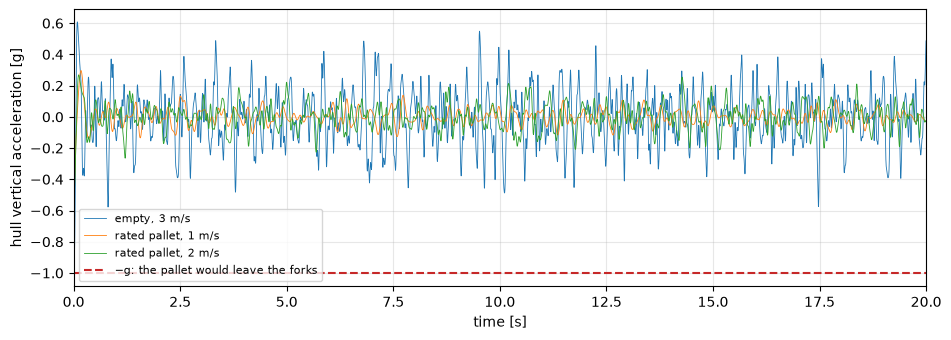

In [11]:
M_UNSPRUNG = orb.PARTS_KG["wheels: tyres + rims 4x"] / 4 + act.get(orb.WHEEL_MOTOR).mass_g / 1000 + budget["lower legs 4x (Al 7075-T6, from CAD)"] / 8
K_TYRE = 150e3
K_SUSP = orb.LEG_KP / LEVER_KNEE ** 2
C_SUSP = orb.LEG_KD / LEVER_KNEE ** 2
def iso8608_profile(length_m, dx, gd_n0, seed, n0=0.1, n_min=0.02, n_max=8.0, n_waves=400):
    rng = np.random.default_rng(seed); x = np.arange(0, length_m, dx)
    ns = np.linspace(n_min, n_max, n_waves); dn = ns[1] - ns[0]
    amps = np.sqrt(2 * gd_n0 * (ns / n0) ** -2 * dn); ph = rng.uniform(0, 2 * math.pi, n_waves)
    return x, (amps[None, :] * np.sin(2 * math.pi * ns[None, :] * x[:, None] + ph[None, :])).sum(axis=1)
def quarter_car(x, z_road, speed, m_s, dt=2e-4):
    t = np.arange(0, x[-1] / speed, dt); zr = np.interp(t * speed, x, z_road)
    zs = zw = vs = vw = 0.0; As, Ft = np.zeros_like(t), np.zeros_like(t)
    for i, z_r in enumerate(zr):
        fs = K_SUSP * (zw - zs) + C_SUSP * (vw - vs); ft = max(K_TYRE * (z_r - zw), -(m_s + M_UNSPRUNG) * G)
        a_s, a_w = fs / m_s, (ft - fs) / M_UNSPRUNG
        vs += a_s * dt; vw += a_w * dt; zs += vs * dt; zw += vw * dt; As[i], Ft[i] = a_s, ft + (m_s + M_UNSPRUNG) * G
    return t, As, Ft
x_road, z_road = iso8608_profile(60.0, 0.005, 256e-6, 5)
F_front_empty = M * G * (X_CG - x_rear) / geo["wheelbase"] / 2
rows, traces = {}, {}
for label, F_corner, speed in (("empty, 3 m/s", F_front_empty, 3.0), ("rated pallet, 1 m/s", F_front, 1.0), ("rated pallet, 2 m/s", F_front, 2.0)):
    m_s = F_corner / G - M_UNSPRUNG
    t_, As, Ft = quarter_car(x_road, z_road, speed, m_s)
    traces[label] = (t_, As)
    rows[label] = {"sprung mass [kg]": m_s, "heave [Hz]": math.sqrt(K_SUSP / m_s) / (2 * math.pi), "hull accel RMS [g]": np.sqrt(np.mean(As ** 2)) / G,
                   "hull accel min [g]": As.min() / G, "time below −g [%]": 100 * np.mean(As < -G), "wheel load max [N]": Ft.max(),
                   "front knee max / stall": Ft.max() * LEVER_KNEE / KNEE.stall_Nm, "wheel airborne [%]": 100 * np.mean(Ft <= 1e-6)}
fig, ax = plt.subplots(figsize=(11, 3.6))
for label, (t_, As) in traces.items():
    ax.plot(t_, As / G, lw=0.6, label=label)
ax.axhline(-1, color="#c62828", ls="--", label="−g: the pallet would leave the forks"); ax.set(xlabel="time [s]", ylabel="hull vertical acceleration [g]", xlim=(0, 20)); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ride = pd.DataFrame(rows).T
ride.round(3)

## 7. The pallet job in MuJoCo (ChironLab)

The Atlas as a Chiron robot (`designs/onager_atlas_robot.py`): the Sentinel chassis's servos and wheels, the mast
on a tilt hinge, the carriage on a slide joint, the forks colliding with the scenery; every drive **four-quadrant**
(it brakes with its full force when backdriven — without it, the first runs showed a mast jolted past its screw's
no-load speed falling forward). The pallet is a Chiron `Prop` (a free body: bottom boards, nine blocks, the deck and
the crate) on a gravel yard. The job (`designs/onager_atlas_scenario.py`) is a `PhasedMission` on top of the
Sentinel drive: forks at travel height, stand off with the tine tips 25 cm short of the pallet, forks to the
openings, creep in, lift, tilt back 5°, carry 8 m at 1 m/s, tilt upright, lower, back out. Nothing about the
pallet is scripted: whether it comes up level, rides on the tines and lands flat is MuJoCo's contact physics.

In [12]:
scene = oas.Scene()
lab = oas.make_lab(scene, robot=robot, log_geoms=True)
ep = oas.run(lab, scene, duration=50.0)
ep.save(RUNS / "pallet_job.npz")
ts = oas.timeseries(ep)
print(f"mission finished: {ep.log['mission_finished']} | events: {ep.log.get('events', [])} | pallet set down at x = {ts.pallet_x.iloc[-1]:.2f} m (mark {scene.x_drop} m), tilt {ts.pallet_tilt_deg.iloc[-1]:.1f}°")
phases = oas.phase_table(ep)
phases.round(2)

mission finished: True | events: [] | pallet set down at x = 13.86 m (mark 14.0 m), tilt 0.3°


,start_s,duration_s,hull_x_m,pallet_z_m,pallet_tilt_deg,lift_force_max_N,tilt_torque_max_Nm,front_knee_max/stall,rear_wheel_min_N
01 forks to travel height,0.00,2.00,-0.48,0.00,0.30,926.72,340.35,0.42,1271.67
02 drive to the pallet,2.00,6.66,2.50,0.00,0.30,1066.77,390.60,0.53,603.34
03 forks to the openings,8.66,1.50,2.51,0.00,0.30,929.62,317.24,0.46,1183.63
04 creep in,10.16,5.58,3.69,0.00,0.30,942.35,605.84,0.52,723.82
05 settle,15.74,0.50,3.68,0.00,0.30,906.35,327.27,0.44,987.43
06 lift,16.24,3.00,3.68,0.15,0.54,3142.76,2201.47,0.76,144.49
07 tilt back,19.24,2.00,3.67,0.22,4.46,2896.86,2034.76,0.77,238.52
08 carry,21.24,10.00,11.68,0.22,4.84,3238.15,2353.34,1.00,0.00
09 settle,31.24,0.50,11.64,0.22,4.53,2880.01,2067.09,0.71,307.17
10 tilt upright,31.74,2.00,11.55,0.14,4.47,2890.15,2080.30,0.83,642.42


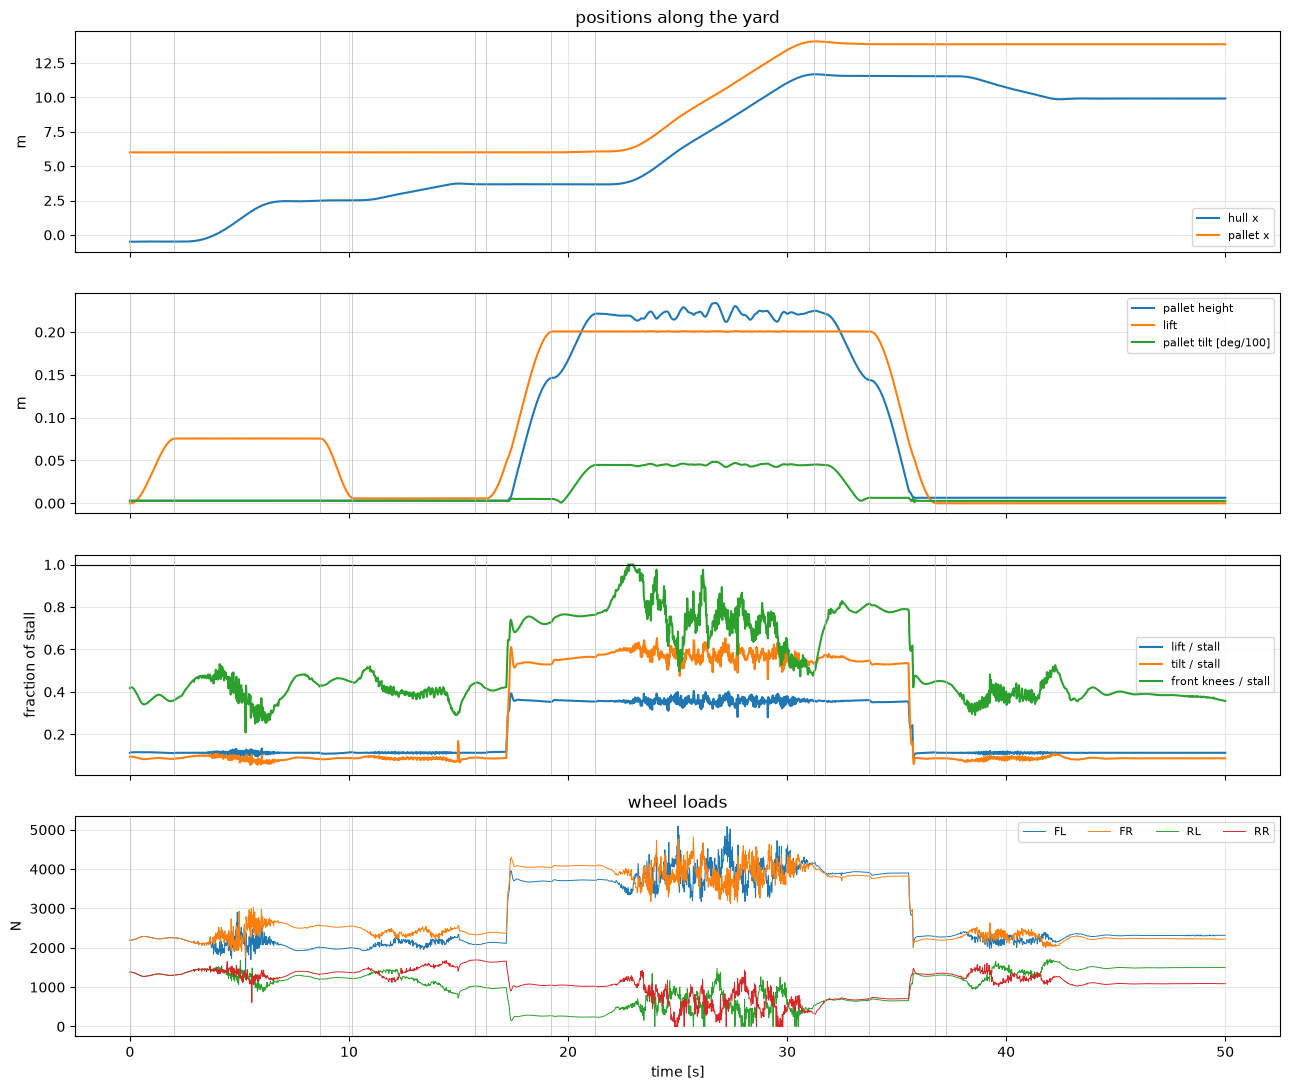

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
axes[0].plot(ts.t, ts.x, label="hull x"); axes[0].plot(ts.t, ts.pallet_x, label="pallet x"); axes[0].set(ylabel="m", title="positions along the yard"); axes[0].legend(fontsize=8)
axes[1].plot(ts.t, ts.pallet_z, label="pallet height"); axes[1].plot(ts.t, ts.lift_m, label="lift"); axes[1].plot(ts.t, ts.pallet_tilt_deg / 100, label="pallet tilt [deg/100]"); axes[1].set(ylabel="m"); axes[1].legend(fontsize=8)
axes[2].plot(ts.t, ts.lift_force_N / LIFT.stall_N, label="lift / stall"); axes[2].plot(ts.t, ts.tilt_torque_Nm / (TILT.stall_N * oar.TILT_LEVER), label="tilt / stall")
axes[2].plot(ts.t, ts[["knee_FL_Nm", "knee_FR_Nm"]].abs().max(axis=1) / KNEE.stall_Nm, label="front knees / stall"); axes[2].axhline(1, color="k", lw=0.8); axes[2].set(ylabel="fraction of stall"); axes[2].legend(fontsize=8)
for wname in ("FL", "FR", "RL", "RR"):
    axes[3].plot(ts.t, ts[f"fz_{wname}"], lw=0.7, label=wname)
axes[3].set(ylabel="N", xlabel="time [s]", title="wheel loads"); axes[3].legend(fontsize=8, ncol=4)
for ax in axes:
    for t0, name, note in ep.log["mission"]:
        if note == "start": ax.axvline(t0, color="#bbb", lw=0.5)
    ax.grid(alpha=0.3)
fig.tight_layout()

movie: output/21_onager_atlas/onager_atlas_pallet.mp4 (1251 frames)


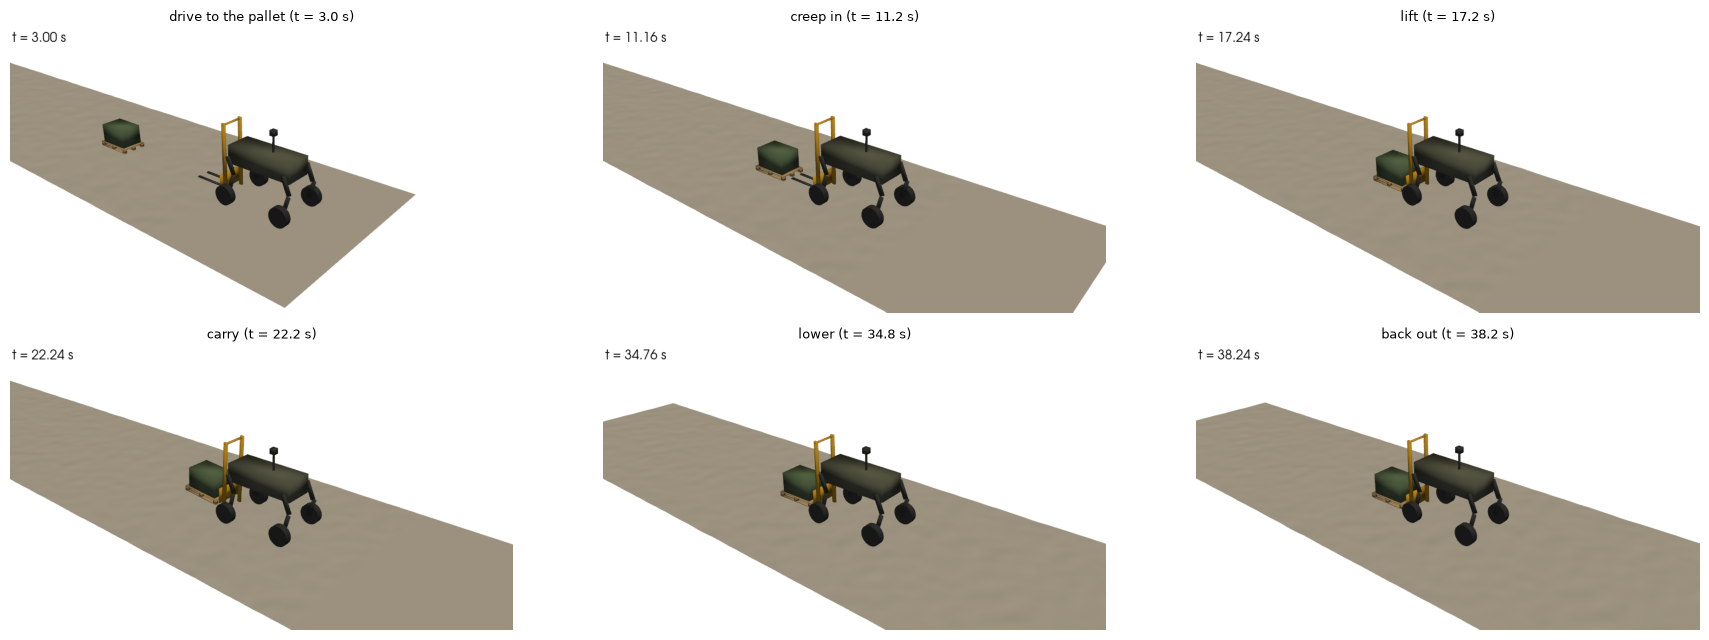

In [14]:
dt = float(ep.log["t"][1] - ep.log["t"][0]); every = max(1, int(round(1 / (25 * dt))))
imgs = cviz.frames(ep, camera="follow", every=every, size=(960, 540))
movie = cviz.to_video(imgs, OUT / "onager_atlas_pallet.mp4", fps=25)
print(f"movie: {movie} ({len(imgs)} frames)")
fig, axes = plt.subplots(2, 3, figsize=(18, 6.5))
starts = {name: t0 for t0, name, note in ep.log["mission"] if note == "start"}
for ax, name in zip(axes.flat, ("drive to the pallet", "creep in", "lift", "carry", "lower", "back out")):
    j = min(len(imgs) - 1, int(round((starts.get(name, 0.0) + 1.0) / (every * dt))))
    ax.imshow(imgs[j]); ax.set_axis_off(); ax.set_title(f"{name} (t = {j * every * dt:.1f} s)", fontsize=9)
fig.tight_layout()

## 8. Export

In [15]:
doc = {"source": "21_onager_atlas", "design": {"file": "designs/onager_atlas.py", "parameters": p}, "targets": TARGETS.to_dict(),
       "mass_kg": M, "mass_budget_kg": budget, "cg_m": {"x": X_CG, "z": Z_CG}, "load_chart": chart.to_dict(orient="index"),
       "stance": stance.to_dict(orient="index"), "drives": {"lift_rated_N": F_rated, "lift_speed_m_s": v_rated, "full_lift_s": t_full, "energy_per_lift_Wh": E_lift},
       "forks": forks.to_dict(orient="index"), "mast_modes_hz": modes_tab.to_dict(orient="index"), "ride": ride.to_dict(orient="index"),
       "pallet_job": {"finished": ep.log["mission_finished"], "events": ep.log.get("events", []), "phases": phases.to_dict(orient="index"),
                      "pallet_final": {"x": float(ts.pallet_x.iloc[-1]), "z": float(ts.pallet_z.iloc[-1]), "tilt_deg": float(ts.pallet_tilt_deg.iloc[-1])}, "movie": str(movie)}}
(RUNS / "onager_atlas.json").write_text(json.dumps(doc, indent=2, default=float))
print("written:", RUNS / "onager_atlas.json")

written: _runs/onager_atlas/onager_atlas.json


**What the numbers say** — read them above; the ones that set the design: the load chart's capacity at 500 mm
against the 200 kg target (tipping with SF 1.5 and the front knees' limit); the stance map (the Sentinel stance
cannot carry a pallet on these modules); the lift screw's share of its stall and continuous force; the forks' proof
case; the mast's first mode with the pallet at full height; and in §7 the front knees' torque while braking with
the pallet — it reaches the modules' stall in the simulation, so 200 kg is the limit of this build, not a margin.

**Next steps an engineer would take:** larger front knee modules (or a 150 kg rating) and a measured
torque–speed curve with the brake's holding torque; side-shift and fork positioners for pallets that are not
centred; a lateral stability check (turning with the load up); the load's sway on the mast as a closed-loop test
in ChironLab (braking from 1 m/s with the pallet at 1.2 m); and a pallet that is not one rigid body (the crate
strapped on a separate deck).